<a href="https://colab.research.google.com/github/Copperhorse/Profanity_Distilbert_LORA/blob/main/ProfanityDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install --upgrade transformers


In [ ]:
import matplotlib.pyplot as plt
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast,
    Trainer,
    TrainingArguments,
)
from sklearn.model_selection import train_test_split
import numpy as np


In [ ]:
import pandas as pd

df = pd.read_parquet("hf://datasets/tarekziade/profanity-clean/data/train-00000-of-00001.parquet")

In [ ]:
df.head()

,is_offensive,text
0,0,Then go to the village pump and suggest they c...
1,1,Dis hoe wasnt dis violent on Lottery Ticket
2,0,It is better for Atabay not helping the banned...
3,0,is in CamelCase SiCKO is not CamelCase so the ...
4,0,Nonetheless lactose has a hemiacetal group whi...


In [ ]:
X = df["text"]
y = df["is_offensive"]

In [ ]:
print(X.head())
print(y.head())

0    Then go to the village pump and suggest they c...
1          Dis hoe wasnt dis violent on Lottery Ticket
2    It is better for Atabay not helping the banned...
3    is in CamelCase SiCKO is not CamelCase so the ...
4    Nonetheless lactose has a hemiacetal group whi...
Name: text, dtype: object
0    0
1    1
2    0
3    0
4    0
Name: is_offensive, dtype: int64


In [ ]:
X_train, X_eval, y_train, y_eval = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y,
)

train_df = pd.DataFrame({"text": X_train, "labels": y_train})
eval_df = pd.DataFrame({"text": X_eval, "labels": y_eval})

In [ ]:
# --------------------------------------------------
# Step 3: Tokenization
# --------------------------------------------------

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256,
    )

# Import Dataset from the datasets library
from datasets import Dataset

# Convert pandas DataFrames to datasets.Dataset objects
train_hf_dataset = Dataset.from_pandas(train_df,preserve_index=False)
eval_hf_dataset = Dataset.from_pandas(eval_df,preserve_index=False)

# Now map the tokenizer over the datasets.Dataset objects
train_dataset = train_hf_dataset.map(tokenize, batched=True)
eval_dataset = eval_hf_dataset.map(tokenize, batched=True)

train_dataset.set_format(
    "torch", columns=["input_ids", "attention_mask", "labels"]
)
eval_dataset.set_format(
    "torch", columns=["input_ids", "attention_mask", "labels"]
)

Map:   0%|          | 0/82099 [00:00<?, ? examples/s]

Map:   0%|          | 0/9123 [00:00<?, ? examples/s]

In [ ]:
# --------------------------------------------------
# Step 4: Model + LoRA
# --------------------------------------------------

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
)

lora_config = LoraConfig(
    task_type="SEQ_CLS",
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "k_lin", "v_lin"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 813,314 || all params: 67,768,324 || trainable%: 1.2001


In [ ]:
# --------------------------------------------------
# Step 5: Training Arguments
# --------------------------------------------------

training_args = TrainingArguments(
    output_dir="./results_profanity",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    logging_dir="./logs",
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# --------------------------------------------------
# Step 6: Metrics
# --------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1).numpy()
    return {"accuracy": accuracy_score(labels, preds)}

In [ ]:
# --------------------------------------------------
# Step 7: Trainer
# --------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-2307075700.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# --------------------------------------------------
# Step 8: Train & Evaluate
# --------------------------------------------------

trainer.train()
results = trainer.evaluate()
print(results)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.129300,0.137430,0.951222
2,0.120700,0.128439,0.953086
3,0.119600,0.125515,0.955936
4,0.117400,0.123299,0.956703
5,0.116200,0.124196,0.956593


{'eval_loss': 0.12329892069101334, 'eval_accuracy': 0.9567028389784062, 'eval_runtime': 19.5828, 'eval_samples_per_second': 465.868, 'eval_steps_per_second': 29.158, 'epoch': 5.0}


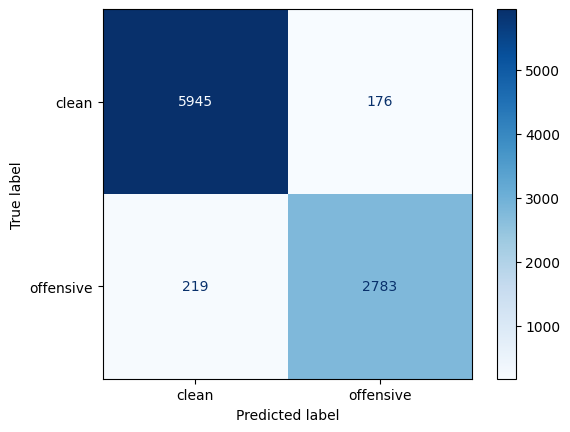

('profanity_classifier_distilbert_lora/tokenizer_config.json',
 'profanity_classifier_distilbert_lora/special_tokens_map.json',
 'profanity_classifier_distilbert_lora/vocab.txt',
 'profanity_classifier_distilbert_lora/added_tokens.json',
 'profanity_classifier_distilbert_lora/tokenizer.json')

In [ ]:
# --------------------------------------------------
# Step 9: Confusion Matrix
# --------------------------------------------------

predictions = trainer.predict(eval_dataset)
y_true = predictions.label_ids
y_pred = torch.argmax(
    torch.tensor(predictions.predictions), dim=1
).numpy()

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(
    cm, display_labels=["clean", "offensive"]
).plot(cmap="Blues")
plt.show()

# --------------------------------------------------
# Step 10: Save Model
# --------------------------------------------------

trainer.save_model("profanity_classifier_distilbert_lora")
tokenizer.save_pretrained("profanity_classifier_distilbert_lora")

Evaluating with base model

In [ ]:
base_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# Trainer only for evaluation
baseline_trainer = Trainer(
    model=base_model,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1014037897.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  baseline_trainer = Trainer(


In [ ]:
baseline_results = baseline_trainer.evaluate()
print("Pre-fine-tuning Accuracy:", baseline_results["eval_accuracy"])


Pre-fine-tuning Accuracy: 0.6708319631700098


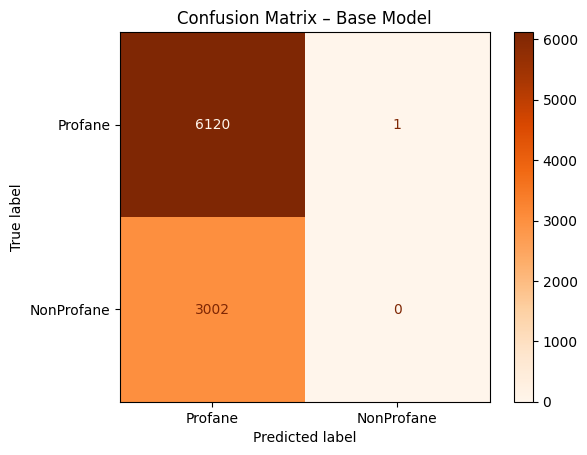

In [ ]:
baseline_pred = baseline_trainer.predict(eval_dataset)
y_true = baseline_pred.label_ids
y_pred = np.argmax(baseline_pred.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Profane", "NonProfane"]
)
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix – Base Model")
plt.show()


In [ ]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define source and destination paths
source_folder = '/content/profanity_classifier_distilbert_lora'
destination_folder = '/content/drive/MyDrive/profanity_classifier_distilbert_lora'

# Check if the source folder exists
if not os.path.exists(source_folder):
    print(f"Error: Source folder '{source_folder}' does not exist.")
else:
    # Check if destination folder already exists, and if so, remove it
    if os.path.exists(destination_folder):
        print(f"Destination folder '{destination_folder}' already exists. Deleting it before copying.")
        shutil.rmtree(destination_folder)

    # Copy the folder
    try:
        shutil.copytree(source_folder, destination_folder)
        print(f"Folder '{source_folder}' successfully copied to '{destination_folder}'")
    except Exception as e:
        print(f"Error copying folder: {e}")

Mounted at /content/drive
Error: Source folder '/content/profanity_classifier_distilbert_lora' does not exist.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
import torch

# Mount drive if not already mounted
from google.colab import drive
drive.mount('/content/drive')

model_path = '/content/drive/MyDrive/profanity_classifier_distilbert_lora'
base_model_name = 'distilbert-base-uncased'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Load base model then attach LoRA adapter
base_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=2
)
model = PeftModel.from_pretrained(base_model, model_path)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import classification_report
import numpy as np
from transformers import Trainer, TrainingArguments

eval_trainer = Trainer(
    model=model,
    processing_class=tokenizer,  # replaces deprecated 'tokenizer'
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

predictions = eval_trainer.predict(eval_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=["clean", "offensive"]))

              precision    recall  f1-score   support

       clean       0.96      0.97      0.97      6121
   offensive       0.94      0.93      0.93      3002

    accuracy                           0.96      9123
   macro avg       0.95      0.95      0.95      9123
weighted avg       0.96      0.96      0.96      9123

